## 트랜스포머 모델을 GPT-1 논문 기반의 Decoder 모델로 변환

## [Transformer와 GPT 아키텍처 비교 및 변경 사항]

1. **구조적 차이 (Encoder 제거)**: 기존 Transformer는 Encoder와 Decoder가 모두 존재함.  
   반면 GPT-1은 언어 모델링(Next-token prediction)을 위한 **Decoder-only 아키텍처**이다.
   따라서 모델 코드에서 `Encoder`와 `EncoderLayer` 블록을 완전히 삭제해야 한다
2. **Decoder Layer의 Attention 변경 (Cross-Attention 제거)**: 기존 Decoder Layer에는 Encoder의 출력값을 참조하는 인코더-디코더 어텐션(Cross-Attention)이 있었음.  
   GPT는 Encoder가 없으므로 이 부분을 삭제하고, 오직 Look-ahead mask가 적용된 **Masked Self-Attention**과 **Feed Forward Network**만 남긴다.
3. **위치 인코딩 (Positional Encoding -> Embedding)**: 기존 모델은 Sine/Cosine 함수를 이용한 고정된 Positional Encoding을 사용했지만, GPT-1 논문에서는 학습 가능한 **Positional Embedding**을 사용.  
   이를 반영하여 `nn.Embedding`으로 위치 정보를 추가하도록 수정함.
4. **입력 데이터 형태 변경 (Pretrain 언어모델 방식)**: 기존에는 질문(Encoder Input)과 답변(Decoder Input)이 분리되어 들어갔으나, GPT는 단일 시퀀스를 입력받아 다음 단어를 예측.  
   따라서 `[BOS] 질문 [EOS] 답변 [EOS]` 형태로 데이터를 하나의 시퀀스로 이어붙여 Autoregressive(자기회귀) 학습을 하도록 데이터셋 구성을 변경.
5. **추론(Inference) 방식 변경**: 질문에 대한 답변을 완전히 분리된 새로운 시퀀스로 생성하는 기존 방식과 달리,
   `[BOS] 질문 [EOS]` 형태의 단일 시퀀스를 그대로 모델에 넣고 **`[EOS]` 토큰 바로 뒤에 이어질 다음 단어를 하나씩 예측하여 기존 문장에 계속 이어 붙이는 방식**으로 추론 함수를 변경.

**변경된 부분 확인하기**
- [GPT 아키텍처 코드](#model-step)
   - [모델 호출](#model-step2)
   - [학습 루프](#model-step3)
- [GPT용 데이터셋 전처리 코드](#dataset-step)
- [Autogressive 추론 함수](#inference-step)

### 데이터 수집

In [1]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-04-21 05:18:59--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-04-21 05:18:59--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  5.64MB/s    in 0.2s    

2026-04-21 05:19:00 (5.64 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



In [2]:
import pandas as pd

data = pd.read_csv('ChatbotData.csv')

In [3]:
data.head(5)

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [4]:
data.sample(5)

,Q,A,label
7001,어찌해야 할까,차분히 생각해봐요.,1
5211,황당해 죽겠다.,너무 신경쓰지마세요.,0
8503,헤어졌는데 아픔보다는 미움.원망,아름다운 이별이란 없어요.,1
1993,방학했더니 심심해,친구들과 연락해보세요.,0
1790,물 많이 마시라고 했는데,습관을 들여보세요.,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


#### [사용할 데이터](https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv)
- 데이터셋 구조  
  1. Q: 사용자의 질문(발화)
  2. A: 챗봇의 답변
  3. label: 감정 분류 (0: 일상, 1: 부정, 2: 긍정)

### 데이터 전처리

In [6]:
# 구두점 제거
def preprocess_sentence(sentence):
    sentence = sentence.strip() # 문장의 양쪽 공백 제거

    # 단어와 구두점 사이 거리 만들기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    sentence = re.sub(r"[^ㄱ-ㅎ가-힣0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

In [7]:
import re

sample_sentence = '안녕하세요? 저는 챗봇입니다, 만나서 반가워요!'

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

안녕하세요 ? 저는 챗봇입니다 , 만나서 반가워요 !


In [8]:
questions = []
answers = []
labels = []

for q, a, l in zip(data['Q'], data['A'], data['label']):
    questions.append(preprocess_sentence(q))
    answers.append(preprocess_sentence(a))
    labels.append(l)

print(f"질문 데이터 개수: {len(questions)}")
print(f"답변 데이터 개수: {len(answers)}")
print(f"라벨 개수: {len(labels)}")

질문 데이터 개수: 11823
답변 데이터 개수: 11823
라벨 개수: 11823


In [9]:
# 질문-답변-라벨 쌍 전처리
def create_pairs(questions, answers, labels):
    pairs = []

    for q, a, l in zip(questions, answers, labels):
        pairs.append((q, a, l))

    return pairs

preprocessed_pairs = create_pairs(questions, answers, labels)

In [10]:
preprocessed_pairs[:5]

[('12시 땡 !', '하루가 또 가네요 .', 0),
 ('1지망 학교 떨어졌어', '위로해 드립니다 .', 0),
 ('3박4일 놀러가고 싶다', '여행은 언제나 좋죠 .', 0),
 ('3박4일 정도 놀러가고 싶다', '여행은 언제나 좋죠 .', 0),
 ('심하네', '눈살이 찌푸려지죠 .', 0)]

In [11]:
preprocessed_pairs[5947]

('너무 힘들어', '지금 무슨 말을 해도 와닿지 않겠지만 잘할 수 있을 거예요 .', 1)

In [12]:
len(preprocessed_pairs)

11823

#### SentencePiece 사용

In [13]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a, l in preprocessed_pairs: #lable은 제외
        f.write(q + '\n')
        f.write(a + '\n')

In [14]:
!pip install sentencepiece

In [15]:
# vocab_size를 8000으로 했더니 6000번대 후반 이후의 단어들은 퀴, 킥, 힣 등 의미없는 한글자로 확인
# vocab_size를 6000으로 변경
# 모델 성능이 좋지 않아서 4000으로 줄임
import sentencepiece as spm

spm.SentencePieceTrainer.Train(
    input = corpus_file,
    model_prefix = 'spm_chatbot',
    vocab_size=4000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,
    eos_id=2,
    pad_id=0,
    unk_id=3
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_corpus.txt
  input_format: 
  model_prefix: spm_chatbot
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differ

In [16]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

True

In [17]:
# 예제 문장
sample = '안녕하세요, 오늘 날씨는 어떤가요?'

sentence = preprocess_sentence(sample)
print("전처리 후의 문장:", sentence)

tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 안녕하세요 , 오늘 날씨는 어떤가요 ?
Tokenized: ['▁안녕', '하세요', '▁,', '▁오늘', '▁날씨', '는', '▁어떤', '가요', '▁?']
Encoded: [1097, 133, 422, 129, 913, 2790, 446, 611, 11]
Decoded: 안녕하세요 , 오늘 날씨는 어떤가요 ?


In [18]:
sample2 = "오늘날씨가너무좋아서공원가고싶다"
print("Pieces:", sp.EncodeAsPieces(sample2))
print("Decoding:", sp.DecodeIds(sp.EncodeAsIds(sample2))) # 원래 문장으로 잘 돌아오는지 확인

Pieces: ['▁오늘', '날', '씨', '가', '너', '무', '좋', '아서', '공', '원', '가고', '싶다']
Decoding: 오늘날씨가너무좋아서공원가고싶다


In [19]:
sample3 = "진짜요?! 그게 정말 사실인가요?"
print("Pieces:", sp.EncodeAsPieces(sample3))

Pieces: ['▁진짜', '요', '?', '!', '▁그게', '▁정말', '▁사실', '인가요', '?']


#### 데이터셋 구현

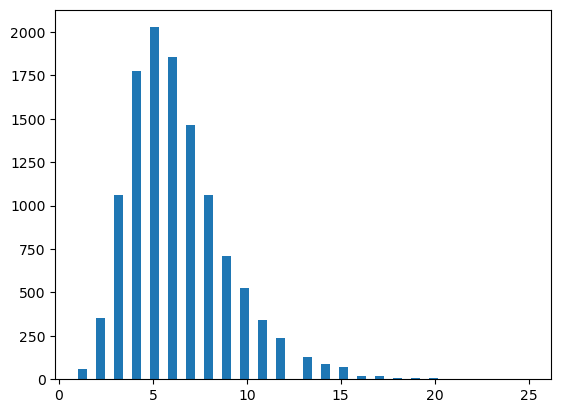

In [20]:
# 문장별 토큰 개수 확인
len_list = [len(sp.EncodeAsIds(q)) for q in questions]
import matplotlib.pyplot as plt
plt.hist(len_list, bins=50)
plt.show()

<a id="dataset-step"></a>
## 데이터셋 전처리 코드 수정 (GPTDataset)

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40): # 문장이 길어지므로 max_length 증가
        self.sp = sp
        self.max_length = max_length
        self.data = []

        bos_id = sp.bos_id()
        eos_id = sp.eos_id()
        pad_id = sp.pad_id()
        
        for q_text, a_text, l in pairs:
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # GPT 구조: <s> 질문 </s> 답변 </s> 형태로 하나의 시퀀스 구성
            tokens = [bos_id] + q_ids + [eos_id] + a_ids + [eos_id]

            # 최대 길이 제한 및 패딩
            if len(tokens) > max_length + 1:
                tokens = tokens[:max_length + 1]
            else:
                tokens += [pad_id] * (max_length + 1 - len(tokens))

            # Input과 Target 생성 (Target은 Input을 한 칸씩 뒤로 미룬 형태)
            input_ids = tokens[:-1]
            target_ids = tokens[1:]

            self.data.append({
                "input_ids": input_ids,
                "target_ids": target_ids
            })

    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        item = self.data[idx]
        return (
            torch.tensor(item["input_ids"]),
            torch.tensor(item["target_ids"])
        )

In [22]:
# dataset = ChatbotDataset(preprocessed_pairs, sp, max_length=20)

In [23]:
# for encoder_input, decoder_input, target, label  in dataset:
#     print("텐서 크기 :",encoder_input.size())
#     print(encoder_input)
#     print(sp.decode(encoder_input.tolist()))
#     print(decoder_input)
#     print(sp.decode(decoder_input.tolist()))
#     print(target)
#     print(sp.decode(target.tolist()))
#     print(label)
#     print(sp.decode(label.tolist()))
#     break

In [24]:
# dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [25]:
# for encoder_input, decoder_input, target, label in dataloader:
#     print(encoder_input.size())
#     print(decoder_input.size())
#     print(target.size())
#     print(label.size())
#     break

#### 데이터셋 나누기

In [26]:
from sklearn.model_selection import train_test_split

# 1. 원본 데이터에서 라벨 리스트만 따로 추출 (preprocessed_pairs가 (q, a, l) 형태인 경우)
labels_for_stratify = [p[2] for p in preprocessed_pairs]

# 2. stratify 옵션에 라벨 리스트를 넣어 균등하게 나누기
train_pairs, test_pairs = train_test_split(
    preprocessed_pairs, 
    test_size=0.1, 
    random_state=42, 
    stratify=labels_for_stratify  # 라벨 비율을 유지하며 나눔
)

# 3. Dataset 생성
# 데이터셋 객체 생성 (기존 train_dataset, test_dataset 생성 부분도 수정)
train_dataset = GPTDataset(train_pairs, sp, max_length=40)
test_dataset = GPTDataset(test_pairs, sp, max_length=40)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"검증 데이터 개수: {len(test_dataset)}")
print(f"총 합계: {len(train_dataset) + len(test_dataset)}")

학습 데이터 개수: 10640
검증 데이터 개수: 1183
총 합계: 11823


In [27]:
BATCH_SIZE = 64

# 학습용 데이터로더 (데이터를 섞어주기 위해 shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 검증용 데이터로더 (섞을 필요 없으므로 shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습용 배치 개수: {len(train_loader)}")
print(f"검증용 배치 개수: {len(test_loader)}")

학습용 배치 개수: 167
검증용 배치 개수: 19


### 모델 구성

In [28]:
# 모델의 하이퍼파라미터 정리
D_MODEL = 128
NUM_LAYERS = 2
NUM_HEADS = 4
D_FF = 256
DROPOUT = 0.1
VOCAB_SIZE = 4000 # 토크나이저 사전 크기
MAX_LENGTH = 35   # 최대 길이

#### Attention, Encoder, Decoder 준비 (실습 코드 사용)

In [29]:
# import torch
import torch.nn as nn
import torch.nn.functional as F
# from torch.utils.data import Dataset
# from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
# import sentencepiece as spm

import math
import os
# import re
import urllib.request
import zipfile
import numpy as np
# import matplotlib.pyplot as plt

In [30]:
# [변경 사항] GPT 모델은 고정된 수학적 Positional Encoding 대신 
# 학습 가능한 Positional Embedding(nn.Embedding)을 사용하므로 
# 아래의 기존 PositionalEncoding 클래스는 사용하지 않아 주석 처리합니다.
# class PositionalEncoding(nn.Module):
#     def __init__(self, position, d_model):
#         super(PositionalEncoding, self).__init__()
#         self.d_model = d_model
#         self.position = position

#         self.pos_encoding = self._build_pos_encoding(position, d_model)

#     def _get_angles(self, position, i, d_model):
#         return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

#     def _build_pos_encoding(self, position, d_model):
#         pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
#         i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

#         angle_rads = self._get_angles(pos, i, d_model)
#         sines = torch.sin(angle_rads[:, 0::2])
#         cosines = torch.cos(angle_rads[:, 1::2])

#         pos_encoding = torch.zeros(position, d_model)
#         pos_encoding[:, 0::2] = sines
#         pos_encoding[:, 1::2] = cosines

#         pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
#         return pos_encoding

#     def forward(self, x):
#         return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [31]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [32]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output

In [33]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask
    
# 이 함수에 정수 시퀀스를 입력으로 하면, 
# 이 함수는 숫자가 0인 부분을 체크한 벡터를 리턴합니다.

In [34]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

<a id = "model-step"></a>
### GPT 모델 아키텍처 구성
- 인코더 레이어 삭제
- 인코더 층 삭제
- DecoderLayer 수정 (cross-attention 삭제)
- Transformer -> GPT 모델로 재구성 (Positional Embedding 반영)

In [35]:
# [변경사항] GPT 모델 구성을 위해 Cross-Attention(encdec_mha) 제거
class GPTDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(GPTDecoderLayer, self).__init__()

        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),                   
            nn.Linear(ff_dim, d_model)   
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, look_ahead_mask=None):
        # 1) Masked Self Attention
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out) 

        # 2) Feed Forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)

        return out2

In [36]:
# [변경사항] 기존 Transformer 클래스를 대체하는 GPT 클래스 작성
class GPT(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, max_length, dropout=0.1):
        super(GPT, self).__init__()
        self.d_model = d_model
        self.max_length = max_length

        # [변경사항] 논문에 기반하여 고정된 PositionalEncoding 대신 학습 가능한 nn.Embedding 사용
        self.tok_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_length, d_model)

        self.dropout = nn.Dropout(dropout)

        # Decoder Layer 쌓기
        self.blocks = nn.ModuleList([
            GPTDecoderLayer(d_model, num_heads, units, dropout)
            for _ in range(num_layers)
        ])

        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs):
        batch_size, seq_len = inputs.size()
        
        # Look-ahead mask와 Padding mask 합성
        look_ahead_mask = create_look_ahead_mask(inputs)

        # 위치 정보 (Positional Embedding)
        positions = torch.arange(0, seq_len).unsqueeze(0).expand(batch_size, seq_len).to(inputs.device)
        
        # Token + Positional Embedding
        x = self.tok_embedding(inputs) * math.sqrt(self.d_model)
        x = x + self.pos_embedding(positions)
        x = self.dropout(x)

        # Decoder Blocks 통과
        for block in self.blocks:
            x = block(x, look_ahead_mask)

        logits = self.final_linear(x)
        return logits

#### 모델 생성

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<a id="model-step2"></a>
## 모델 생성 - GPT 클래스 호출로 변경

In [38]:
# 변경된 코드
MAX_LENGTH = 40 # 데이터셋 전처리에서 설정한 길이와 동일하게 맞춤

model = GPT(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS, # 기존 인코더/디코더 레이어 수를 하나로 통일 (예: 2~4)
    units=D_FF,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_length=MAX_LENGTH, # 새로 추가된 위치 임베딩용 인자
    dropout=DROPOUT
).to(device)

print(model)

GPT(
  (tok_embedding): Embedding(4000, 128)
  (pos_embedding): Embedding(40, 128)
  (dropout): Dropout(p=0.3, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x GPTDecoderLayer(
      (self_mha): MultiHeadAttention(
        (query_dense): Linear(in_features=128, out_features=128, bias=True)
        (key_dense): Linear(in_features=128, out_features=128, bias=True)
        (value_dense): Linear(in_features=128, out_features=128, bias=True)
        (out_dense): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (dropout1): Dropout(p=0.3, inplace=False)
      (dropout2): Dropout(p=0.3, inplace=False)
    )
  )
  (final_linear): Linear(in_features=128, o

#### 모델 컴파일

In [39]:
# 손실함수 정의
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [40]:
# 스케줄러 사용 준비
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

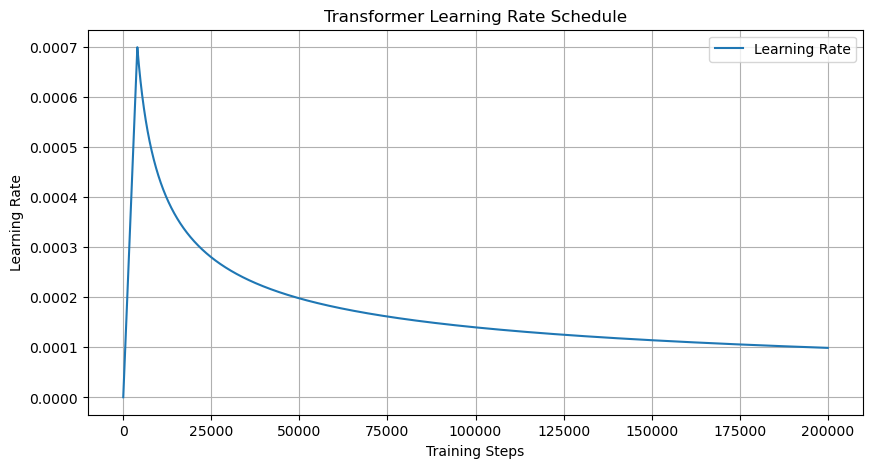

In [41]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

#### 모델 학습

<a id="model-step3"></a>
## 학습 루프 변경 (입력 데이터가 변경 되었음)

In [43]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    # [변경사항] 입력과 타겟만 언패킹
    inputs, targets = [x.to(device) for x in batch] 

    optimizer.zero_grad()
    logits = model(inputs) # 모델에 inputs만 전달

    loss = loss_function(logits.permute(0, 2, 1), targets)

    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, targets, pad_id=sp.pad_id())

In [44]:
def train(model, train_loader, test_loader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    # 기록을 위한 리스트 생성
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # 학습 단계
        model.train()
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = total_acc / len(train_loader)

        # 검증 단계
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                # [변경됨] 언패킹 변수 축소
                inputs, targets = [x.to(device) for x in batch]
                # [변경됨] inputs 하나만 모델에 전달
                logits = model(inputs)
                loss = loss_function(logits.permute(0, 2, 1), targets)
                acc = accuracy_function(logits, targets, pad_id=sp.pad_id())
                
                val_loss += loss.item()
                val_acc += acc.item()
        
        avg_val_loss = val_loss / len(test_loader)
        avg_val_acc = val_acc / len(test_loader)

        # --- 기록 저장 ---
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(avg_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        
        print(f"Epoch {epoch+1} Completed")
        print(f"Train - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
        print(f"Val   - Avg Loss: {avg_val_loss:.4f}, Avg Acc: {avg_val_acc:.4f}")
        print("-" * 40)

    return history # 시각화에 사용할 기록 반환

[Epoch 1, Step 0] Loss: 8.4251, Acc: 0.0000
[Epoch 1, Step 100] Loss: 6.8534, Acc: 0.1399
Epoch 1 Completed
Train - Avg Loss: 7.2782, Avg Acc: 0.1120
Val   - Avg Loss: 6.3336, Avg Acc: 0.1879
----------------------------------------
[Epoch 2, Step 0] Loss: 6.3127, Acc: 0.1813
[Epoch 2, Step 100] Loss: 6.1675, Acc: 0.1898
Epoch 2 Completed
Train - Avg Loss: 6.1084, Avg Acc: 0.1980
Val   - Avg Loss: 5.8272, Avg Acc: 0.2053
----------------------------------------
[Epoch 3, Step 0] Loss: 5.8093, Acc: 0.2041
[Epoch 3, Step 100] Loss: 5.6291, Acc: 0.2088
Epoch 3 Completed
Train - Avg Loss: 5.6796, Avg Acc: 0.2103
Val   - Avg Loss: 5.4453, Avg Acc: 0.2190
----------------------------------------
[Epoch 4, Step 0] Loss: 5.3301, Acc: 0.2297
[Epoch 4, Step 100] Loss: 5.1967, Acc: 0.2261
Epoch 4 Completed
Train - Avg Loss: 5.2895, Avg Acc: 0.2264
Val   - Avg Loss: 5.1089, Avg Acc: 0.2368
----------------------------------------
[Epoch 5, Step 0] Loss: 4.9686, Acc: 0.2297
[Epoch 5, Step 100] Loss

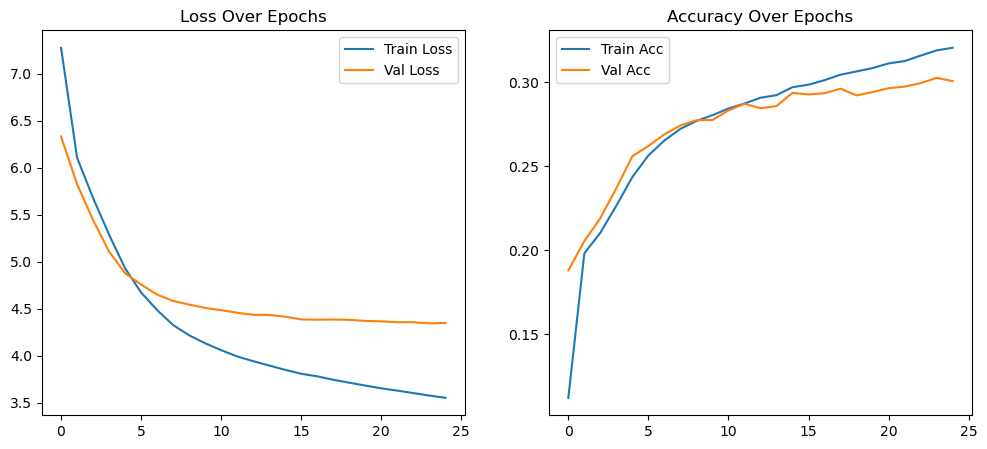

CPU times: user 1min 43s, sys: 415 ms, total: 1min 44s
Wall time: 52.7 s


In [45]:
%%time

history = train(
    model=model,
    train_loader=train_loader,  
    test_loader=test_loader,  
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,
    device=device
)

# GPU에 저장된 텐서 값들을 CPU용 숫자(float)로 변환
history['train_acc'] = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in history['train_acc']]
history['val_acc'] = [acc.cpu().item() if torch.is_tensor(acc) else acc for acc in history['val_acc']]

# 만약 Loss도 에러가 난다면 동일하게 처리 (보통 item()을 써서 이미 숫자일 확률이 높지만 안전하게)
history['train_loss'] = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in history['train_loss']]
history['val_loss'] = [loss.cpu().item() if torch.is_tensor(loss) else loss for loss in history['val_loss']]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs'); plt.legend()

plt.show()

### 모델 평가

<a id="inference-step"></a>
## 모델 추론 및 답변 생성
- GPT는 단일 문장 뒤에 이어질 단어를 예측함 -> 생성을 위한 inference 코드도 변경

In [46]:
def gpt_inference(model, sentence, tokenizer, max_gen_len=20, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()

    # 입력 문장 인코딩: <s> 질문 </s> 까지 만들어서 모델에 던짐
    sentence = preprocess_sentence(sentence)
    input_ids = [START_TOKEN] + tokenizer.EncodeAsIds(sentence) + [END_TOKEN]
    
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for _ in range(max_gen_len):
            logits = model(input_tensor)
            
            # 마지막 단어 예측
            last_step_logits = logits[:, -1, :]
            predicted_id = torch.argmax(last_step_logits, dim=-1).unsqueeze(1)

            # EOS 토큰이 나오면 멈춤
            if predicted_id.item() == END_TOKEN:
                break

            # 생성된 단어를 입력 텐서 뒤에 이어 붙임 (Autoregressive)
            input_tensor = torch.cat([input_tensor, predicted_id], dim=1)

    # 처음 입력했던 질문 부분을 제외하고 새로 생성된 답변 부분만 반환
    input_len = len(input_ids)
    generated_ids = input_tensor.squeeze(0).tolist()[input_len:]
    return generated_ids

def sentence_generation(model, sentence, tokenizer, device='cpu'):
    output_seq = gpt_inference(model, sentence, tokenizer, device=device)
    predicted_sentence = tokenizer.decode(output_seq)

    print(f"입력 : {sentence}")
    print(f"출력 : {predicted_sentence}")
    return predicted_sentence

In [47]:
sentence = '안녕? 잘 지냈어?'
sentence_generation(model, sentence, sp, device)

입력 : 안녕? 잘 지냈어?
출력 : 잘 어울리는 게 좋을 것 같아요 .


'잘 어울리는 게 좋을 것 같아요 .'

In [48]:
sentence = '오늘 기분 어때?'
sentence_generation(model, sentence, sp, device)

입력 : 오늘 기분 어때?
출력 : 소개팅 시켜달라고 말해보세요 .


'소개팅 시켜달라고 말해보세요 .'

In [49]:
sentence = '오늘 너의 기분은?'
sentence_generation(model, sentence, sp, device)

입력 : 오늘 너의 기분은?
출력 : 다른 생각을 했나봐요 .


'다른 생각을 했나봐요 .'

In [57]:
sentence = '나는 오늘 슬퍼'
sentence_generation(model, sentence, sp, device)

입력 : 나는 오늘 슬퍼
출력 : 다른 생각을 했나봐요 .


'다른 생각을 했나봐요 .'

In [51]:
sentence = "오늘 회사에서 힘들었어"
sentence_generation(model, sentence, sp, device)

입력 : 오늘 회사에서 힘들었어
출력 : 제가 위로해 드릴게요 .


'제가 위로해 드릴게요 .'

In [52]:
sentence = "비 오는 날에는 어떤 음식이 좋을까?"
sentence_generation(model, sentence, sp, device)

입력 : 비 오는 날에는 어떤 음식이 좋을까?
출력 : 우산 챙기 마련이죠 .


'우산 챙기 마련이죠 .'

In [53]:
sentence = "친구랑 싸웠는데 어떡하지?"
sentence_generation(model, sentence, sp, device)

입력 : 친구랑 싸웠는데 어떡하지?
출력 : 직접 물어보세요 .


'직접 물어보세요 .'

In [54]:
sentence = "짝사랑하는 사람이 생겼어"
sentence_generation(model, sentence, sp, device)

입력 : 짝사랑하는 사람이 생겼어
출력 : 마음이 복잡하겠어요 .


'마음이 복잡하겠어요 .'

In [55]:
sentence = "심심하다 놀아줘"
sentence_generation(model, sentence, sp, device)

입력 : 심심하다 놀아줘
출력 : 좋은 사람 만날 수 있을 거예요 .


'좋은 사람 만날 수 있을 거예요 .'

## 회고 (평가기준 달성 부분 캡쳐)
1. Transformer와 비교해 변경이 필요한 부분을 서술  
   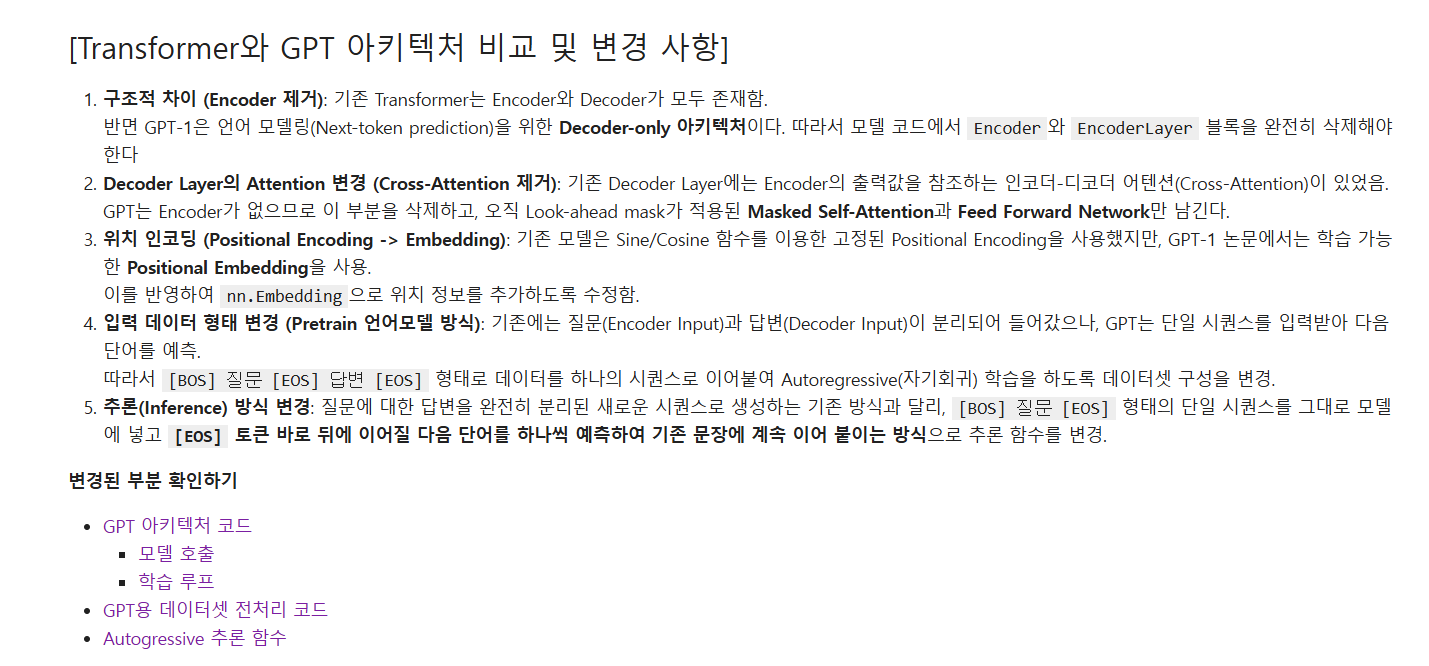
2. 모델의 입력 형태에 맞게 전처리를 수행  
   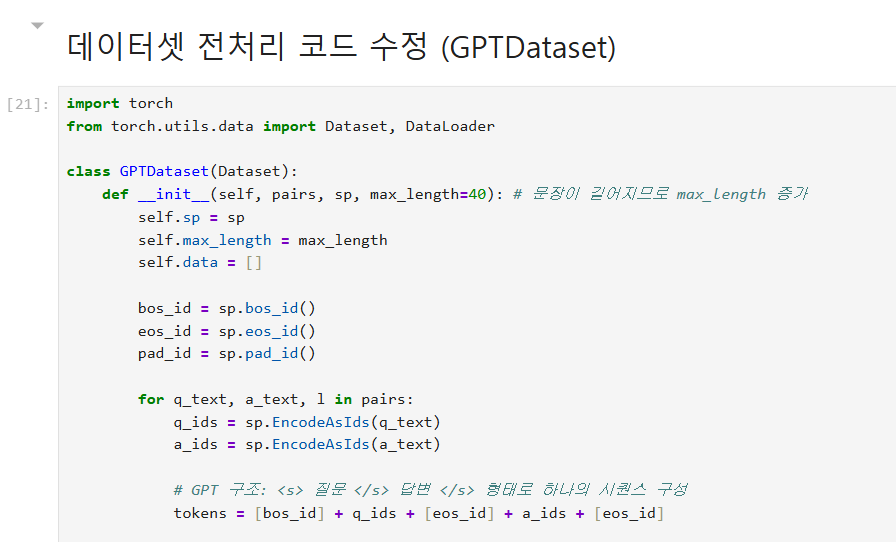
3. 모델의 입력 블럭을 GPT 논뭄ㄴ에 기반하여 수정  
   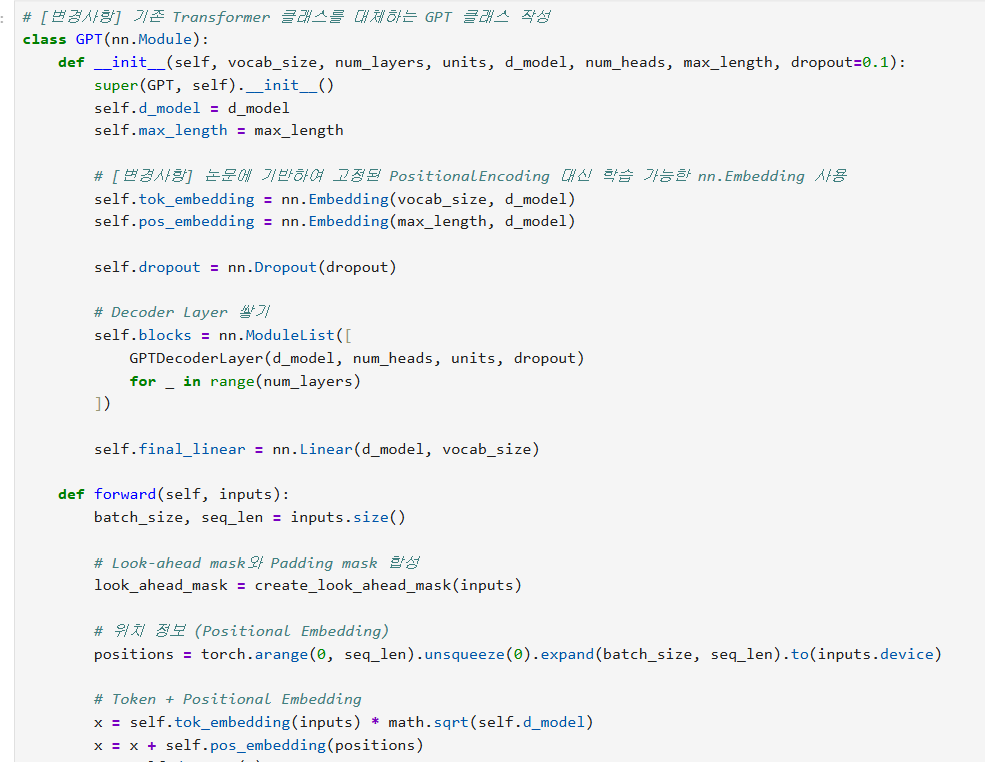
4. GPT 모델을 정상적으로 구현 (model.summary, model.fit 결과 캡쳐 첨부)  
   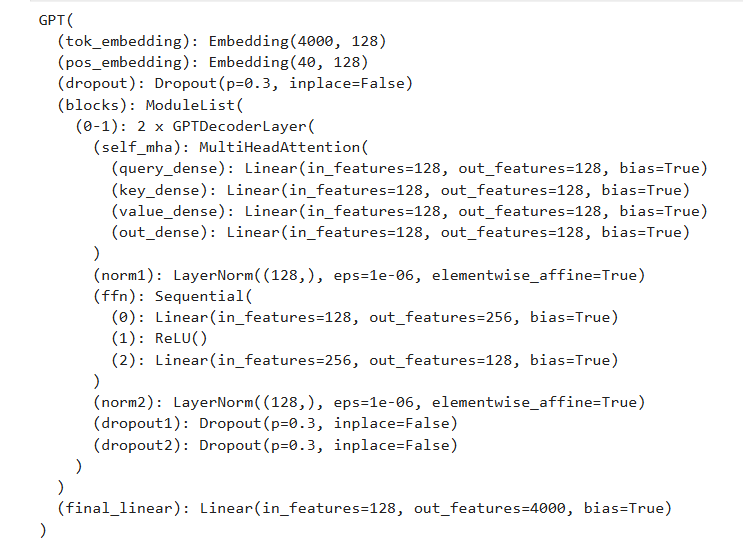
   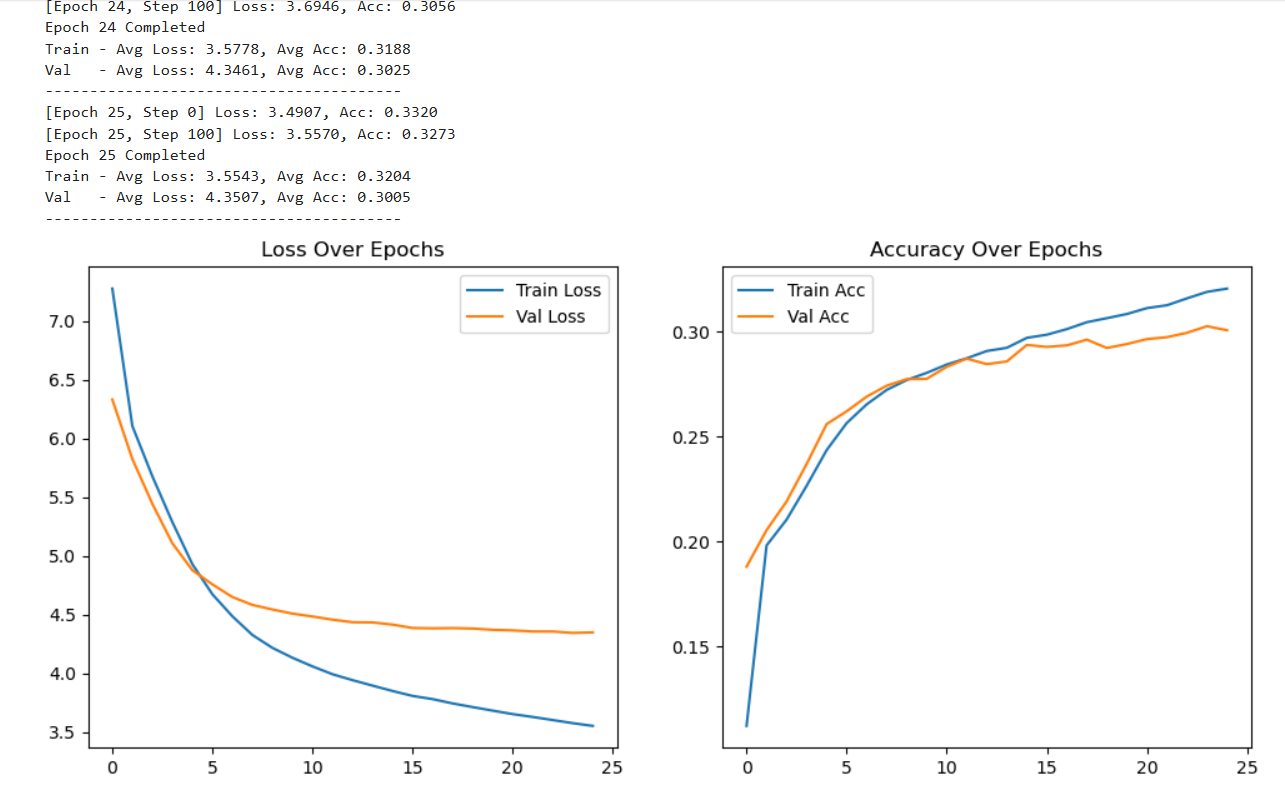
5. 입력에 따른 출력이 생성  
   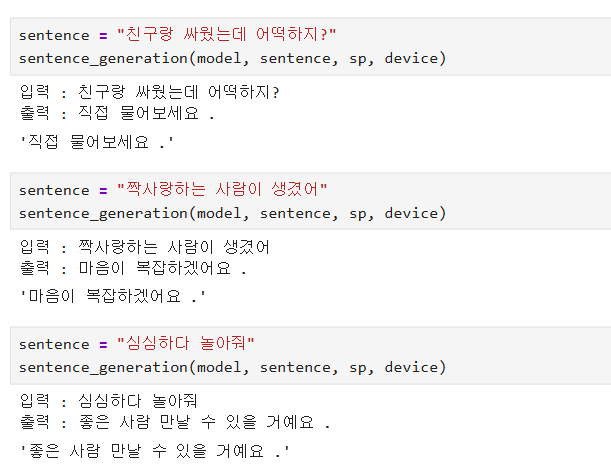